In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential,Model
from tensorflow.keras.layers import Input,SimpleRNN,LSTM,GRU,Dense,Dropout,GlobalAveragePooling2D,RepeatVector
from tensorflow.keras.applications import MobileNetV2
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix
import cv2
tf.random.set_seed(42)
np.random.seed(42)
output_dir='/kaggle/working/plots'
os.makedirs(output_dir,exist_ok=True)


In [2]:
uci_root='/kaggle/input/datasets/uciml/human-activity-recognition-with-smartphones'
if not os.path.exists(uci_root):
    uci_root='/kaggle/input/human-activity-recognition-with-smartphones'
train_csv=f'{uci_root}/train.csv'
test_csv=f'{uci_root}/test.csv'
if not os.path.exists(train_csv):
    raise FileNotFoundError(f"UCI HAR dataset not found at {train_csv}!")
df_train=pd.read_csv(train_csv)
df_test=pd.read_csv(test_csv)
label_col='Activity'
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
le.fit(pd.concat([df_train[label_col],df_test[label_col]]))
y_all=le.transform(df_train[label_col])
X_all=df_train.drop(columns=[label_col,'subject']).values.astype(np.float32)
num_features=9
timesteps=X_all.shape[1]//num_features
X_all=X_all[:,:timesteps*num_features].reshape(-1,timesteps,num_features)
subset_idx=np.random.choice(len(X_all),min(3000,len(X_all)),replace=False)
X_raw=X_all[subset_idx]
y_raw=y_all[subset_idx]
mean=np.mean(X_raw,axis=(0,1))
std=np.std(X_raw,axis=(0,1))
X_norm=(X_raw-mean)/(std+1e-7)
X_temp,X_test,y_temp,y_test=train_test_split(X_norm,y_raw,test_size=0.15,random_state=42)
X_train,X_val,y_train,y_val=train_test_split(X_temp,y_temp,test_size=0.15/0.85,random_state=42)
print("Training:",X_train.shape)
print("Validation:",X_val.shape)
print("Testing:",X_test.shape)

Training: (2099, 62, 9)
Validation: (451, 62, 9)
Testing: (450, 62, 9)


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


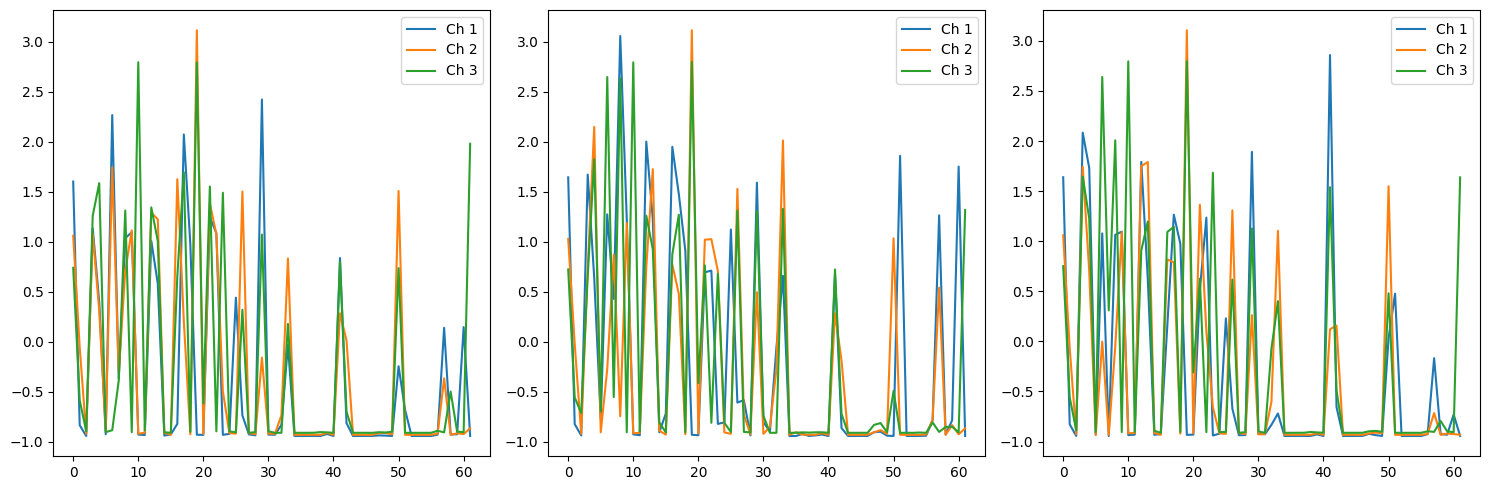

In [3]:
plt.figure(figsize=(15,5))
sample_idx=[np.where(y_train==i)[0][0] for i in range(3)]
for i,idx in enumerate(sample_idx):
    plt.subplot(1,3,i+1)
    plt.plot(X_train[idx,:,0],label='Ch 1')
    plt.plot(X_train[idx,:,1],label='Ch 2')
    plt.plot(X_train[idx,:,2],label='Ch 3')
    plt.legend()
plt.tight_layout()
plt.savefig(f'{output_dir}/plot1_sensor_signals.eps',format='eps')
plt.show()


In [4]:
x=[0.5,0.7,0.2]
h0=0
Wx=0.5
Wh=0.8
b=0.1
h=h0
for i,xi in enumerate(x):
    h=np.tanh(Wx*xi+Wh*h+b)
    print(f"h_{i+1}={h:.4f}")


h_1=0.3364
h_2=0.6164
h_3=0.6000


In [5]:
def build_model(cell_type='RNN',units=32,input_shape=(X_train.shape[1],X_train.shape[2]),num_classes=6):
    model=Sequential()
    if cell_type=='RNN':
        model.add(SimpleRNN(units,input_shape=input_shape))
    elif cell_type=='LSTM':
        model.add(LSTM(units,input_shape=input_shape))
    elif cell_type=='GRU':
        model.add(GRU(units,input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(Dense(16,activation='relu'))
    model.add(Dense(num_classes,activation='softmax'))
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),loss='sparse_categorical_crossentropy',metrics=['accuracy'])
    return model
models={}
histories={}
train_times={}
for cell in ['RNN','LSTM','GRU']:
    model=build_model(cell_type=cell)
    start_time=time.time()
    history=model.fit(X_train,y_train,validation_data=(X_val,y_val),batch_size=32,epochs=30,verbose=0)
    train_times[cell]=time.time()-start_time
    models[cell]=model
    histories[cell]=history
    print(f"{cell} done")


I0000 00:00:1789885715.368816      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789885715.372441      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
I0000 00:00:1789885721.163613     137 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


RNN done
LSTM done
GRU done


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


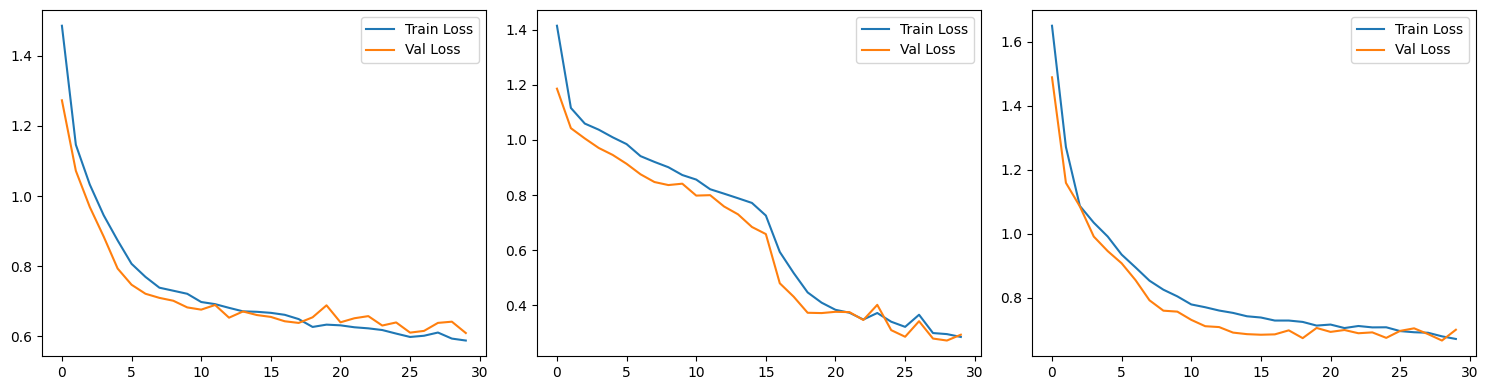

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


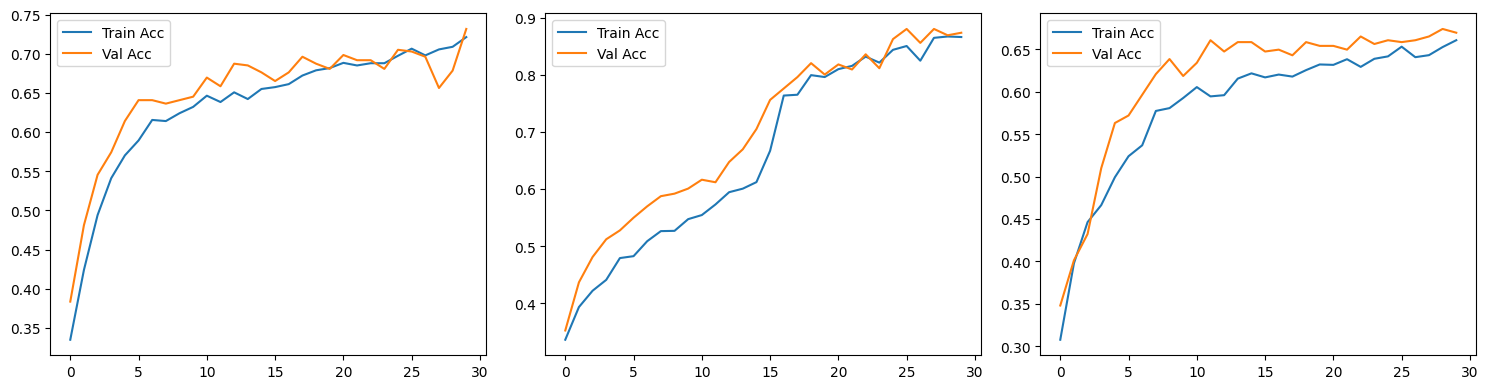

In [6]:
plt.figure(figsize=(15,4))
for i,cell in enumerate(['RNN','LSTM','GRU']):
    plt.subplot(1,3,i+1)
    plt.plot(histories[cell].history['loss'],label='Train Loss')
    plt.plot(histories[cell].history['val_loss'],label='Val Loss')
    plt.legend()
plt.tight_layout()
plt.savefig(f'{output_dir}/plot2_loss.eps',format='eps')
plt.show()
plt.figure(figsize=(15,4))
for i,cell in enumerate(['RNN','LSTM','GRU']):
    plt.subplot(1,3,i+1)
    plt.plot(histories[cell].history['accuracy'],label='Train Acc')
    plt.plot(histories[cell].history['val_accuracy'],label='Val Acc')
    plt.legend()
plt.tight_layout()
plt.savefig(f'{output_dir}/plot3_accuracy.eps',format='eps')
plt.show()


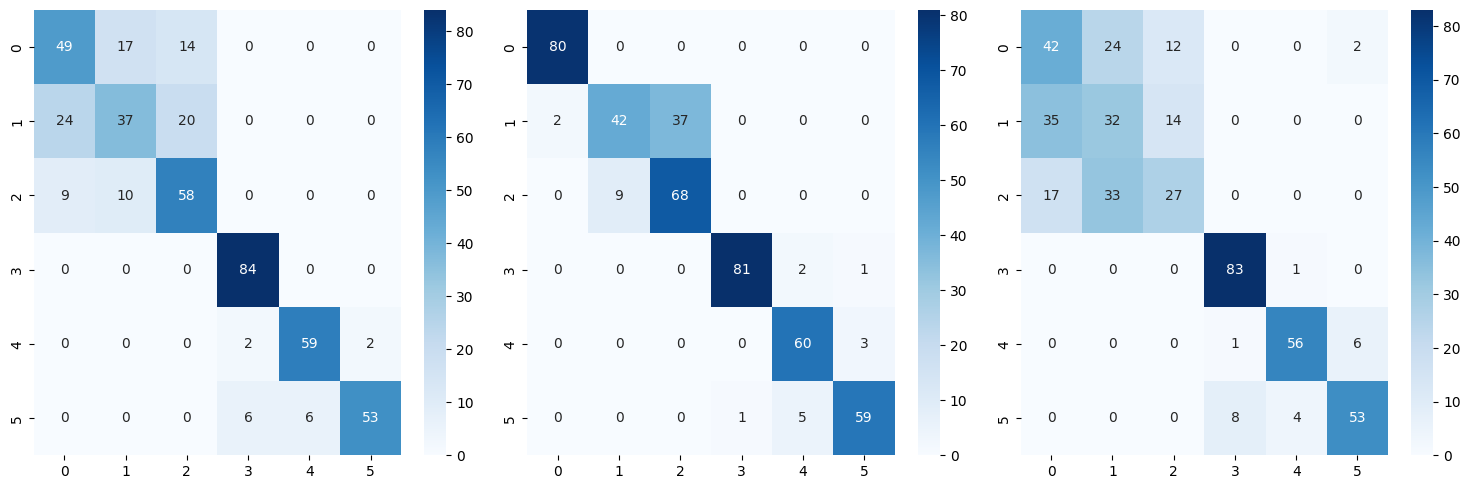

,Accuracy,Macro Precision,Macro Recall,Macro F1,Parameters,Training Time(s)
RNN,0.755556,0.765082,0.762405,0.760238,1974.0,20.618096
LSTM,0.866667,0.877766,0.870999,0.865354,6006.0,21.024795
GRU,0.651111,0.667475,0.660513,0.660382,4758.0,17.663619


In [7]:
results={}
plt.figure(figsize=(15,5))
for i,cell in enumerate(['RNN','LSTM','GRU']):
    model=models[cell]
    y_pred=np.argmax(model.predict(X_test,verbose=0),axis=1)
    acc=accuracy_score(y_test,y_pred)
    prec=precision_score(y_test,y_pred,average='macro',zero_division=0)
    rec=recall_score(y_test,y_pred,average='macro',zero_division=0)
    f1=f1_score(y_test,y_pred,average='macro',zero_division=0)
    params=model.count_params()
    results[cell]={'Accuracy':acc,'Macro Precision':prec,'Macro Recall':rec,'Macro F1':f1,'Parameters':params,'Training Time(s)':train_times[cell]}
    cm=confusion_matrix(y_test,y_pred)
    plt.subplot(1,3,i+1)
    sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.tight_layout()
plt.savefig(f'{output_dir}/plot4_confusion_matrices.eps',format='eps')
plt.show()
results_df=pd.DataFrame(results).T
display(results_df)


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


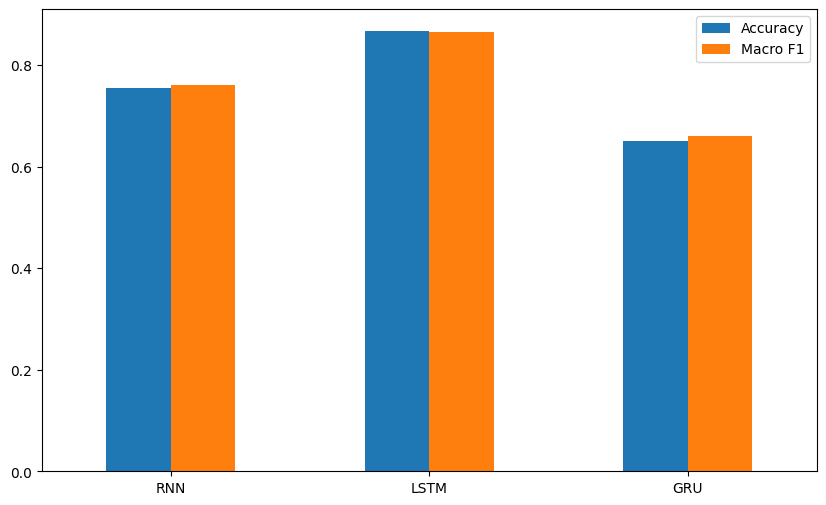

In [8]:
results_df[['Accuracy','Macro F1']].plot(kind='bar',figsize=(10,6))
plt.xticks(rotation=0)
plt.savefig(f'{output_dir}/plot5_performance.eps',format='eps')
plt.show()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a l

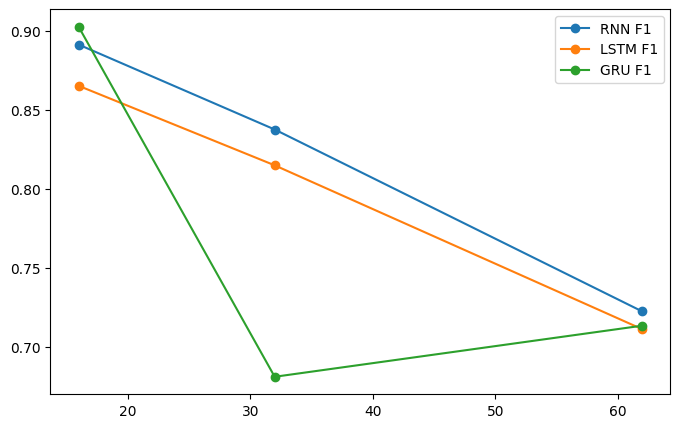

In [9]:
seq_lengths=[16,32,X_train.shape[1]]
f1_scores_len={'RNN':[],'LSTM':[],'GRU':[]}
for length in seq_lengths:
    X_train_trunc=X_train[:,:length,:]
    X_val_trunc=X_val[:,:length,:]
    X_test_trunc=X_test[:,:length,:]
    for cell in ['RNN','LSTM','GRU']:
        model=build_model(cell_type=cell,input_shape=(length,X_train.shape[2]))
        model.fit(X_train_trunc,y_train,validation_data=(X_val_trunc,y_val),batch_size=32,epochs=15,verbose=0)
        y_pred=np.argmax(model.predict(X_test_trunc,verbose=0),axis=1)
        f1_scores_len[cell].append(f1_score(y_test,y_pred,average='macro',zero_division=0))
plt.figure(figsize=(8,5))
for cell in ['RNN','LSTM','GRU']:
    plt.plot(seq_lengths,f1_scores_len[cell],marker='o',label=f'{cell} F1')
plt.legend()
plt.savefig(f'{output_dir}/plot6_seq_length.eps',format='eps')
plt.show()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


2026-09-20 06:31:26.498118: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-20 06:31:26.634391: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-20 06:31:37.551644: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-20 06:31:37.688492: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


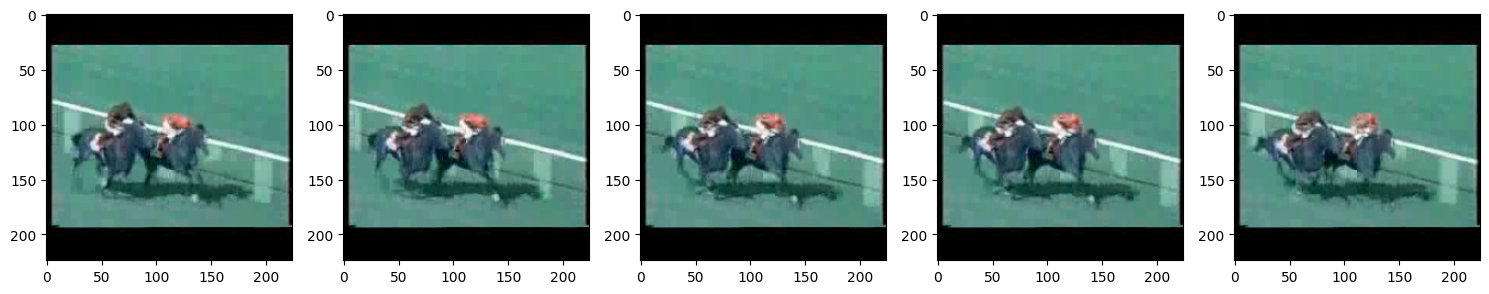

In [10]:
ucf_base_path='/kaggle/input/datasets/pevogam/ucf101/UCF101/UCF-101/'
if not os.path.exists(ucf_base_path):
    ucf_base_path='/kaggle/input/pevogam/ucf101/UCF101/UCF-101/'
if not os.path.exists(ucf_base_path):
    raise FileNotFoundError("UCF101 dataset not found! Please add it.")
classes=[d for d in os.listdir(ucf_base_path) if os.path.isdir(os.path.join(ucf_base_path,d))][:5]
video_frames=[]
video_labels=[]
num_frames=10
for label,cls in enumerate(classes):
    vids=os.listdir(os.path.join(ucf_base_path,cls))[:4]
    for vid in vids:
        cap=cv2.VideoCapture(os.path.join(ucf_base_path,cls,vid))
        frames=[]
        while len(frames)<num_frames:
            ret,frame=cap.read()
            if not ret: break
            frame=cv2.resize(frame,(224,224))
            frames.append(frame)
        cap.release()
        if len(frames)==num_frames:
            video_frames.append(frames)
            video_labels.append(label)
video_frames=np.array(video_frames,dtype=np.float32)
video_labels=np.array(video_labels)
num_videos=len(video_labels)
video_classes=len(classes)
base_cnn=MobileNetV2(weights='imagenet',include_top=False,input_shape=(224,224,3))
cnn_extractor=Sequential([base_cnn,GlobalAveragePooling2D()])
base_cnn.trainable=False
flat_frames=video_frames.reshape(-1,224,224,3)/255.0
features_flat=cnn_extractor.predict(flat_frames,batch_size=16,verbose=0)
features=features_flat.reshape(num_videos,num_frames,-1)
plt.figure(figsize=(15,3))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(video_frames[0,i].astype(np.uint8))
plt.tight_layout()
plt.savefig(f'{output_dir}/plot7_video_frames.eps',format='eps')
plt.show()


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


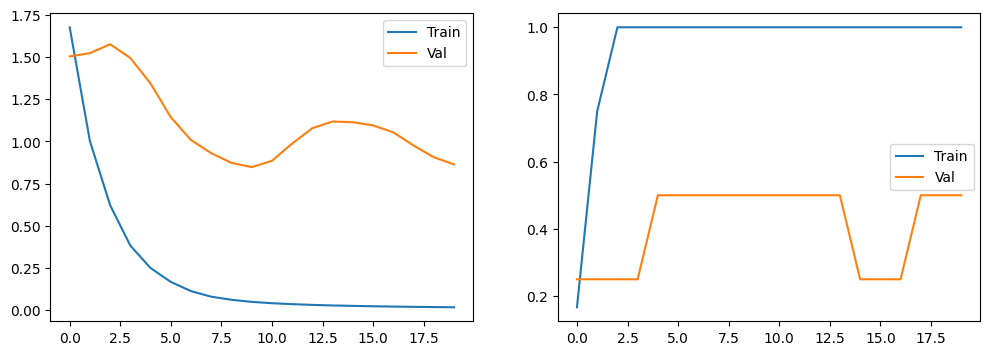

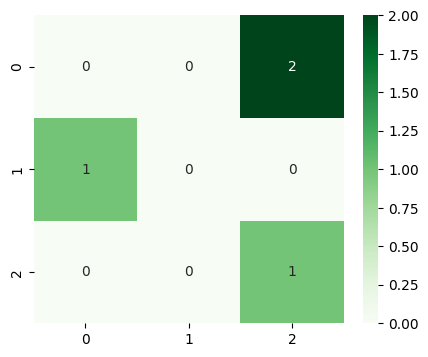

In [11]:
v_train_x,v_test_x,v_train_y,v_test_y=train_test_split(features,video_labels,test_size=0.2,random_state=42)
video_model=Sequential([Input(shape=(num_frames,features.shape[-1])),LSTM(32),Dense(video_classes,activation='softmax')])
video_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
video_history=video_model.fit(v_train_x,v_train_y,validation_split=0.2,epochs=20,verbose=0)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(video_history.history['loss'],label='Train')
plt.plot(video_history.history['val_loss'],label='Val')
plt.legend()
plt.subplot(1,2,2)
plt.plot(video_history.history['accuracy'],label='Train')
plt.plot(video_history.history['val_accuracy'],label='Val')
plt.legend()
plt.savefig(f'{output_dir}/plot8_video_curves.eps',format='eps')
plt.show()
v_pred=np.argmax(video_model.predict(v_test_x,verbose=0),axis=1)
cm_vid=confusion_matrix(v_test_y,v_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm_vid,annot=True,cmap='Greens')
plt.savefig(f'{output_dir}/plot9_video_cm.eps',format='eps')
plt.show()


In [12]:
num_seqs=5000
seq_len=5
vocab_size=10
X_seq=np.random.randint(1,vocab_size,size=(num_seqs,seq_len))
y_seq=np.flip(X_seq,axis=1)
X_seq_oh=tf.keras.utils.to_categorical(X_seq,num_classes=vocab_size)
y_seq_oh=tf.keras.utils.to_categorical(y_seq,num_classes=vocab_size)
s_train_x,s_test_x,s_train_y,s_test_y=train_test_split(X_seq_oh,y_seq_oh,test_size=0.2)
encoder_inputs=Input(shape=(seq_len,vocab_size))
encoder=LSTM(32,return_state=True)
encoder_outputs,state_h,state_c=encoder(encoder_inputs)
encoder_states=[state_h,state_c]
decoder_inputs=RepeatVector(seq_len)(encoder_outputs)
decoder_lstm=LSTM(32,return_sequences=True)(decoder_inputs,initial_state=encoder_states)
decoder_dense=Dense(vocab_size,activation='softmax')(decoder_lstm)
seq2seq=Model(encoder_inputs,decoder_dense)
seq2seq.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
seq2seq.fit(s_train_x,s_train_y,validation_split=0.2,epochs=20,batch_size=64,verbose=0)
y_pred_seq_probs=seq2seq.predict(s_test_x,verbose=0)
y_pred_seq=np.argmax(y_pred_seq_probs,axis=-1)
y_true_seq=np.argmax(s_test_y,axis=-1)
token_acc=np.sum(y_pred_seq==y_true_seq)/y_true_seq.size
seq_acc=np.sum(np.all(y_pred_seq==y_true_seq,axis=1))/y_true_seq.shape[0]
print(f"Token Accuracy: {token_acc:.4f}")
print(f"Sequence Accuracy: {seq_acc:.4f}")


Token Accuracy: 0.7172
Sequence Accuracy: 0.1640
